<a href="https://colab.research.google.com/github/danielmarinho10-sudo/Inteligencia-Artificial-para-Seguranca-em-Bancos/blob/main/Projeto_de_IA_antifraude_Fase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# O pandas serve para criar e mexer em tabelas de dados (como se fossem planilhas do Excel)
import pandas as pd

# O numpy faz cálculos matemáticos avançados e lida com números e aleatoriedade
import numpy as np

# O matplotlib cria gráficos básicos (linhas, barras, etc.)
import matplotlib.pyplot as plt

# O seaborn deixa os gráficos mais bonitos e fáceis de visualizar
import seaborn as sns

# Do scikit-learn (biblioteca principal de Inteligência Artificial), pegamos:
# 1. train_test_split: para separar nossos dados entre treino e teste
# 2. StratifiedKFold e cross_val_score: para fazer testes repetidos em várias partes dos dados
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# StandardScaler: serve para deixar os números de colunas diferentes no mesmo "tamanho" ou escala
from sklearn.preprocessing import StandardScaler

# LogisticRegression: nosso primeiro algoritmo de IA, mais simples e rápido
from sklearn.linear_model import LogisticRegression

# RandomForestClassifier: nosso segundo algoritmo de IA, cria centenas de "árvores de decisão"
from sklearn.ensemble import RandomForestClassifier

# Ferramentas para medir se os modelos estão acertando ou errando bastante:
from sklearn.metrics import (
    classification_report,       # Mostra um resumo com notas do modelo (precisão, recall, etc.)
    confusion_matrix,            # Tabela que mostra quantos acertos e erros o modelo teve
    roc_curve,                   # Ajuda a desenhar a curva de desempenho do modelo
    roc_auc_score,               # Nota final do desempenho geral (vai de 0 a 1)
    average_precision_score      # Medida especial para problemas com poucas fraudes
)

# Ferramentas avançadas da biblioteca imblearn:
# SMOTE: cria fraudes "falsas" (sintéticas) para ensinar o modelo a reconhecer padrões raros
from imblearn.over_sampling import SMOTE

# ImbPipeline: junta o SMOTE com o modelo sem "vazar" dados do teste
from imblearn.pipeline import Pipeline as ImbPipeline

# GridSearchCV: testa várias configurações no modelo de forma automática até achar a melhor
from sklearn.model_selection import GridSearchCV

# Definimos uma "semente" fixa para que os resultados aleatórios sejam idênticos toda vez que rodar
np.random.seed(42)

print("PARTE 1 CONCLUÍDA: Todas as ferramentas foram carregadas no computador!")

PARTE 1 CONCLUÍDA: Todas as ferramentas foram carregadas no computador!


In [3]:
# Lê o arquivo de dados em formato CSV e salva dentro da variável 'dados'
dados = pd.read_csv("creditcard.csv")

# Troca o nome da coluna de resultado de "Class" para "fraude" (para ficar em português)
dados = dados.rename(columns={"Class": "fraude"})

# Conta quantas transações normais (0) e quantas fraudes (1) existem na base
contagem = dados["fraude"].value_counts()

# Descobre a porcentagem exata de fraudes dividindo o total de fraudes pelo total de dados
percentual = dados["fraude"].mean() * 100

# Exibe as informações na tela para o usuário ver
print(f"\nPARTE 2 CONCLUÍDA:")
print(f"Total de compras na tabela: {len(dados)}")
print(f"Compras normais (0): {contagem[0]}")
print(f"Compras com fraude (1): {contagem[1]}")
print(f"Apenas {percentual:.2f}% das compras são fraudes! (Base muito desbalanceada)")


PARTE 2 CONCLUÍDA:
Total de compras na tabela: 9965
Compras normais (0): 9926
Compras com fraude (1): 38
Apenas 0.38% das compras são fraudes! (Base muito desbalanceada)


In [7]:
# Remove a coluna 'Time' (tempo em segundos) porque ela não ajuda a prever fraudes futuras
# O 'errors="ignore"' garante que o código não dará erro se a coluna já tiver sido removida em uma execução anterior.
dados = dados.drop(columns=["Time"], errors="ignore")

# Processa a coluna 'Amount' apenas se ela existir
if "Amount" in dados.columns:
    # A coluna 'Amount' (valor em dinheiro da compra) tem números muito altos (ex: R$ 5.000).
    # Vamos transformar essa coluna usando o StandardScaler para que ela fique na mesma escala das outras
    scaler = StandardScaler()
    dados["Amount_scaled"] = scaler.fit_transform(dados[["Amount"]])

    # Apagamos a coluna 'Amount' original desregulada, mantendo só a nova 'Amount_scaled'
    dados = dados.drop(columns=["Amount"])

# Remove linhas com valores NaN, pois o train_test_split não consegue lidar com eles, especialmente com stratify=y
dados = dados.dropna()

# Criamos a variável X, que contém todas as "pistas" do cartão (valores das colunas, exceto a coluna fraude)
X = dados.drop(columns=["fraude"])

# Criamos a variável y, que contém apenas a resposta ("0" se for normal, "1" se for fraude)
y = dados["fraude"]

# Separamos 80% dos dados para o modelo estudar (treino) e 20% para fazermos o teste final (teste)
# O stratify=y garante que a proporção minúscula de fraudes fique igual nos dois grupos
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nPARTE 3 CONCLUÍDA:")
print(f"Linhas para treinar o modelo: {len(X_treino)}")
print(f"Linhas para testar o modelo: {len(X_teste)}")


PARTE 3 CONCLUÍDA:
Linhas para treinar o modelo: 7971
Linhas para testar o modelo: 1993


In [8]:
# Criamos o primeiro robô de IA (Regressão Logística).
# O parâmetro class_weight="balanced" avisa ao robô que fraudes são raras e merecem atenção dobrada
modelo_lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

# O comando .fit() é onde o robô "lê" os dados de treino e aprende os padrões
modelo_lr.fit(X_treino, y_treino)

# Calculamos a probabilidade de 0 a 100% que o modelo atribui a cada compra de teste ser uma fraude
probas_lr = modelo_lr.predict_proba(X_teste)[:, 1]

print("\nPARTE 4 CONCLUÍDA: Modelo de Regressão Logística treinado!")


PARTE 4 CONCLUÍDA: Modelo de Regressão Logística treinado!


In [9]:
# Criamos o segundo robô (Random Forest), que junta 200 árvores de decisão para tomar uma nota final
modelo_rf = RandomForestClassifier(
    n_estimators=200,          # Usará 200 árvores juntas
    max_depth=8,               # Cada árvore pode ter no máximo 8 níveis de perguntas
    class_weight="balanced_subsample", # Compensa a falta de exemplos de fraude
    random_state=42,           # Mantém o resultado reproduzível
    n_jobs=-1                  # Usa todos os núcleos do processador para andar mais rápido
)

# O robô aprende observando os dados de treino
modelo_rf.fit(X_treino, y_treino)

# Calculamos a probabilidade de fraude para o grupo de teste
probas_rf = modelo_rf.predict_proba(X_teste)[:, 1]

print("PARTE 5 CONCLUÍDA: Modelo de Random Forest treinado!")

PARTE 5 CONCLUÍDA: Modelo de Random Forest treinado!


In [10]:
# Pedimos para a Random Forest dar o veredito simples: 0 (Normal) ou 1 (Fraude) nas compras de teste
previsoes_rf = modelo_rf.predict(X_teste)

print("\n--- PARTE 6: RELATÓRIO DE DESEMPENHO DA RANDOM FOREST ---")
# Exibe a Precisão (quantos alarmes de fraude eram reais) e o Recall (quantas fraudes ele pegou no total)
print(classification_report(y_teste, previsoes_rf, target_names=["Normal", "Fraude"]))

# Calcula a nota AUPRC (quanto maior essa nota entre 0 e 1, melhor o modelo lida com fraudes raras)
pr_auc_rf = average_precision_score(y_teste, probas_rf)
print(f"Nota AUPRC (Precisão x Recall) do modelo: {pr_auc_rf:.4f}")


--- PARTE 6: RELATÓRIO DE DESEMPENHO DA RANDOM FOREST ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1985
      Fraude       1.00      0.62      0.77         8

    accuracy                           1.00      1993
   macro avg       1.00      0.81      0.88      1993
weighted avg       1.00      1.00      1.00      1993

Nota AUPRC (Precisão x Recall) do modelo: 0.9861


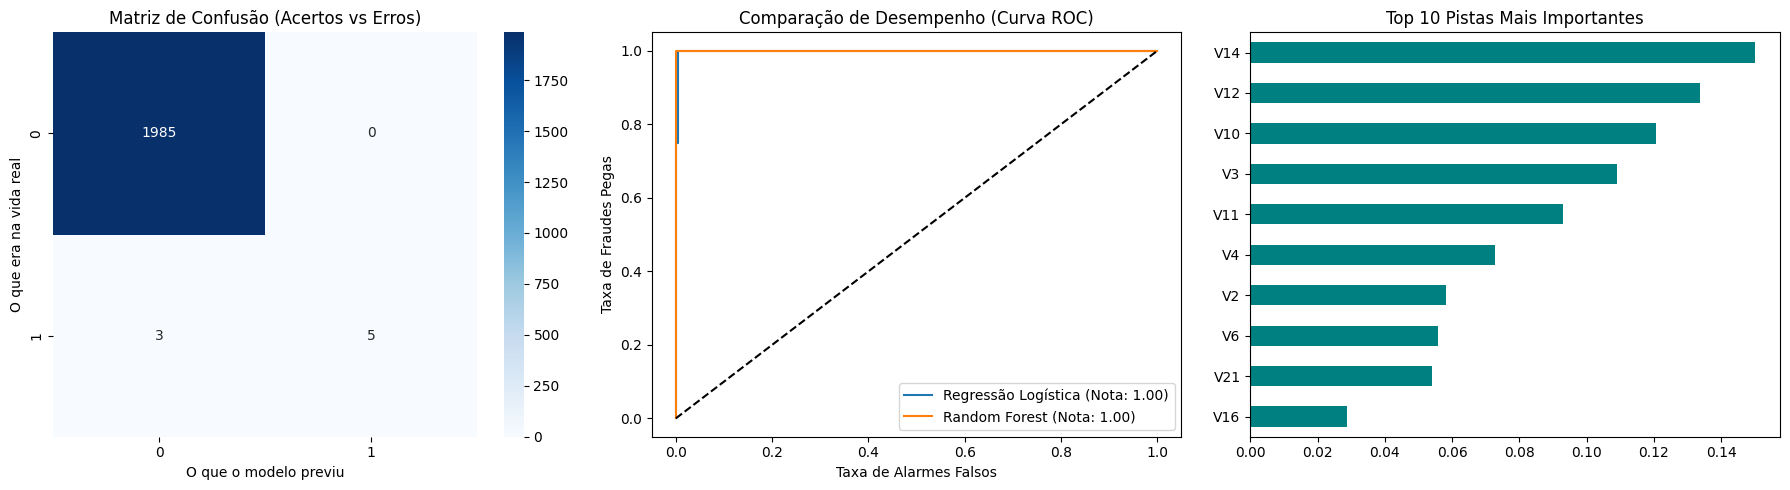

PARTE 7 CONCLUÍDA: Gráficos gerados com sucesso!


In [11]:
# Cria uma janela para desenhar 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Desenha a Matriz de Confusão em azul (quantos acertos e erros diretos)
sns.heatmap(confusion_matrix(y_teste, previsoes_rf), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de Confusão (Acertos vs Erros)")
axes[0].set_xlabel("O que o modelo previu")
axes[0].set_ylabel("O que era na vida real")

# Gráfico 2: Compara as curvas de desempenho dos dois modelos (ROC Curve)
fpr_lr, tpr_lr, _ = roc_curve(y_teste, probas_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_teste, probas_rf)

axes[1].plot(fpr_lr, tpr_lr, label=f'Regressão Logística (Nota: {roc_auc_score(y_teste, probas_lr):.2f})')
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (Nota: {roc_auc_score(y_teste, probas_rf):.2f})')
axes[1].plot([0, 1], [0, 1], 'k--') # Linha pontilhada neutra
axes[1].set_title("Comparação de Desempenho (Curva ROC)")
axes[1].set_xlabel("Taxa de Alarmes Falsos")
axes[1].set_ylabel("Taxa de Fraudes Pegas")
axes[1].legend()

# Gráfico 3: Mostra as 10 colunas da tabela que mais ajudaram o modelo a descobrir a fraude
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias.nlargest(10).sort_values().plot(kind="barh", ax=axes[2], color="teal")
axes[2].set_title("Top 10 Pistas Mais Importantes")

plt.tight_layout() # Ajusta as margens para não embolar
plt.show()         # Exibe a figura com os gráficos na tela

print("PARTE 7 CONCLUÍDA: Gráficos gerados com sucesso!")

In [12]:
# Dividimos os dados em 5 partes para garantir que o modelo não deu "sorte" só na primeira divisão
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Roda o treinamento 5 vezes, cada hora usando uma fatia diferente como teste
scores_cv = cross_val_score(modelo_rf, X, y, cv=cv, scoring='average_precision', n_jobs=-1)

print(f"\nPARTE 8 CONCLUÍDA:")
print(f"Média das notas nas 5 rodadas de teste: {scores_cv.mean():.4f}")


PARTE 8 CONCLUÍDA:
Média das notas nas 5 rodadas de teste: 0.9690


In [13]:
# Por padrão, o modelo só avisa fraude se tiver mais de 50% de certeza.
# Vamos mudar a régua (threshold) para 30%: se tiver 30% ou mais de suspeita, marca como fraude!
novo_threshold = 0.30

# Se a probabilidade for maior ou igual a 0.30, vira 1 (fraude). Se não, vira 0 (normal).
novas_previsoes = (probas_rf >= novo_threshold).astype(int)

print(f"\n--- PARTE 9: AVALIAÇÃO COM SENSIBILIDADE EM {novo_threshold*100:.0f}% ---")
print(classification_report(y_teste, novas_previsoes, target_names=["Normal", "Fraude"]))


--- PARTE 9: AVALIAÇÃO COM SENSIBILIDADE EM 30% ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1985
      Fraude       1.00      0.62      0.77         8

    accuracy                           1.00      1993
   macro avg       1.00      0.81      0.88      1993
weighted avg       1.00      1.00      1.00      1993



In [14]:
print("\n--- PARTE 10: MELHORIAS AVANÇADAS (SMOTE E BUSCA AUTOMÁTICA) ---")

# 1. Aplica o SMOTE nos dados de treino para inventar "fraudes simuladas" baseadas nas reais
smote = SMOTE(random_state=42)
X_treino_resampled, y_treino_resampled = smote.fit_resample(X_treino, y_treino)

print(f"Exemplos de treino antes do SMOTE: {len(X_treino)} (Fraudes: {sum(y_treino == 1)})")
print(f"Exemplos de treino depois do SMOTE: {len(X_treino_resampled)} (Fraudes: {sum(y_treino_resampled == 1)})")

# 2. Montamos uma linha de montagem (Pipeline) que aplica o SMOTE e roda o modelo
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# 3. Opções de receitas/configurações que queremos que o robô teste
param_grid = {
    'model__n_estimators': [100, 200],   # Testa com 100 e depois 200 árvores
    'model__max_depth': [6, 10]          # Testa profundidade 6 e depois 10
}

# 4. O GridSearchCV testa as combinações e escolhe a campeã
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='average_precision',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("\nBuscando a melhor combinação de configurações para o modelo...")
grid_search.fit(X_treino, y_treino)

print("\nMelhor receita de configuração encontrada:")
print(grid_search.best_params_)

# 5. Avaliamos o modelo campeão com os dados de teste finais
melhor_modelo = grid_search.best_estimator_
previsoes_otimizadas = melhor_modelo.predict(X_teste)
probas_otimizadas = melhor_modelo.predict_proba(X_teste)[:, 1]

print("\n--- RELATÓRIO DO MODELO FINAL OTIMIZADO ---")
print(classification_report(y_teste, previsoes_otimizadas, target_names=["Normal", "Fraude"]))

pr_auc_otimizado = average_precision_score(y_teste, probas_otimizadas)
print(f"Nota final de precisão do modelo otimizado: {pr_auc_otimizado:.4f}")
print("\nPROJETO CONCLUÍDO COM SUCESSO!")


--- PARTE 10: MELHORIAS AVANÇADAS (SMOTE E BUSCA AUTOMÁTICA) ---
Exemplos de treino antes do SMOTE: 7971 (Fraudes: 30)
Exemplos de treino depois do SMOTE: 15882 (Fraudes: 7941)

Buscando a melhor combinação de configurações para o modelo...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Melhor receita de configuração encontrada:
{'model__max_depth': 6, 'model__n_estimators': 100}

--- RELATÓRIO DO MODELO FINAL OTIMIZADO ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1985
      Fraude       1.00      0.75      0.86         8

    accuracy                           1.00      1993
   macro avg       1.00      0.88      0.93      1993
weighted avg       1.00      1.00      1.00      1993

Nota final de precisão do modelo otimizado: 0.9705

PROJETO CONCLUÍDO COM SUCESSO!
